# 📊 Telecom Customer Churn & Cohort Analysis
**Dataset:** Telco Customer Churn (Kaggle) — 7,043 customers · 21 features  
**Tools:** Python · Pandas · Seaborn · Matplotlib  
**Goal:** Identify who churns, when they churn, and quantify revenue at risk

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#f0f0f0',
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
    'font.size':        12,
})

CHURN_COLOR    = '#E24B4A'   # red   — churned
RETAIN_COLOR   = '#1D9E75'   # green — retained
NEUTRAL_COLOR  = '#7F77DD'   # purple — neutral
PALETTE        = [RETAIN_COLOR, CHURN_COLOR]

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('Telco-Customer-Churn.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Cleaning & Preprocessing

In [3]:
# ── 2.1  Fix TotalCharges (blank strings → NaN → float) ─────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_before = df['TotalCharges'].isna().sum()
print(f'TotalCharges nulls before fix: {missing_before}')

# These 11 customers have tenure=0; impute TotalCharges with MonthlyCharges
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges']
print(f'TotalCharges nulls after fix : {df["TotalCharges"].isna().sum()}')

TotalCharges nulls before fix: 11
TotalCharges nulls after fix : 0


In [4]:
# ── 2.2  Standardise column names ────────────────────────────────────────────
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# ── 2.3  Encode churn as binary ──────────────────────────────────────────────
df['churn_flag'] = (df['churn'] == 'Yes').astype(int)

# ── 2.4  Verify no remaining nulls ──────────────────────────────────────────
print('Null counts per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f'\nFinal shape: {df.shape}')
print(f'Churn distribution:\n{df["churn"].value_counts()}')

Null counts per column:
Series([], dtype: int64)

Final shape: (7043, 22)
Churn distribution:
churn
No     5174
Yes    1869
Name: count, dtype: int64


In [5]:
# ── 2.5  Feature engineering: tenure groups ──────────────────────────────────
bins   = [0, 12, 24, 36, 48, 60, 72]
labels = ['0–12 mo', '13–24 mo', '25–36 mo', '37–48 mo', '49–60 mo', '61–72 mo']

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print('Tenure group distribution:')
print(df['tenure_group'].value_counts().sort_index())

Tenure group distribution:
tenure_group
0–12 mo     2186
13–24 mo    1024
25–36 mo     832
37–48 mo     762
49–60 mo     832
61–72 mo    1407
Name: count, dtype: int64


## 3. Exploratory Data Analysis
### 3.1 Overall Churn Rate

In [6]:
total      = len(df)
churned    = df['churn_flag'].sum()
retained   = total - churned
churn_rate = churned / total * 100

monthly_revenue_at_risk = df[df['churn_flag'] == 1]['monthlycharges'].sum()
annual_revenue_at_risk  = monthly_revenue_at_risk * 12

print('=' * 42)
print(f'  Total customers      : {total:,}')
print(f'  Churned              : {churned:,}')
print(f'  Retained             : {retained:,}')
print(f'  Churn rate           : {churn_rate:.1f}%')
print(f'  Monthly revenue @ risk: ${monthly_revenue_at_risk:,.0f}')
print(f'  Annual  revenue @ risk: ${annual_revenue_at_risk:,.0f}')
print('=' * 42)

  Total customers      : 7,043
  Churned              : 1,869
  Retained             : 5,174
  Churn rate           : 26.5%
  Monthly revenue @ risk: $139,131
  Annual  revenue @ risk: $1,669,570


### 3.2 Churn by Key Segments

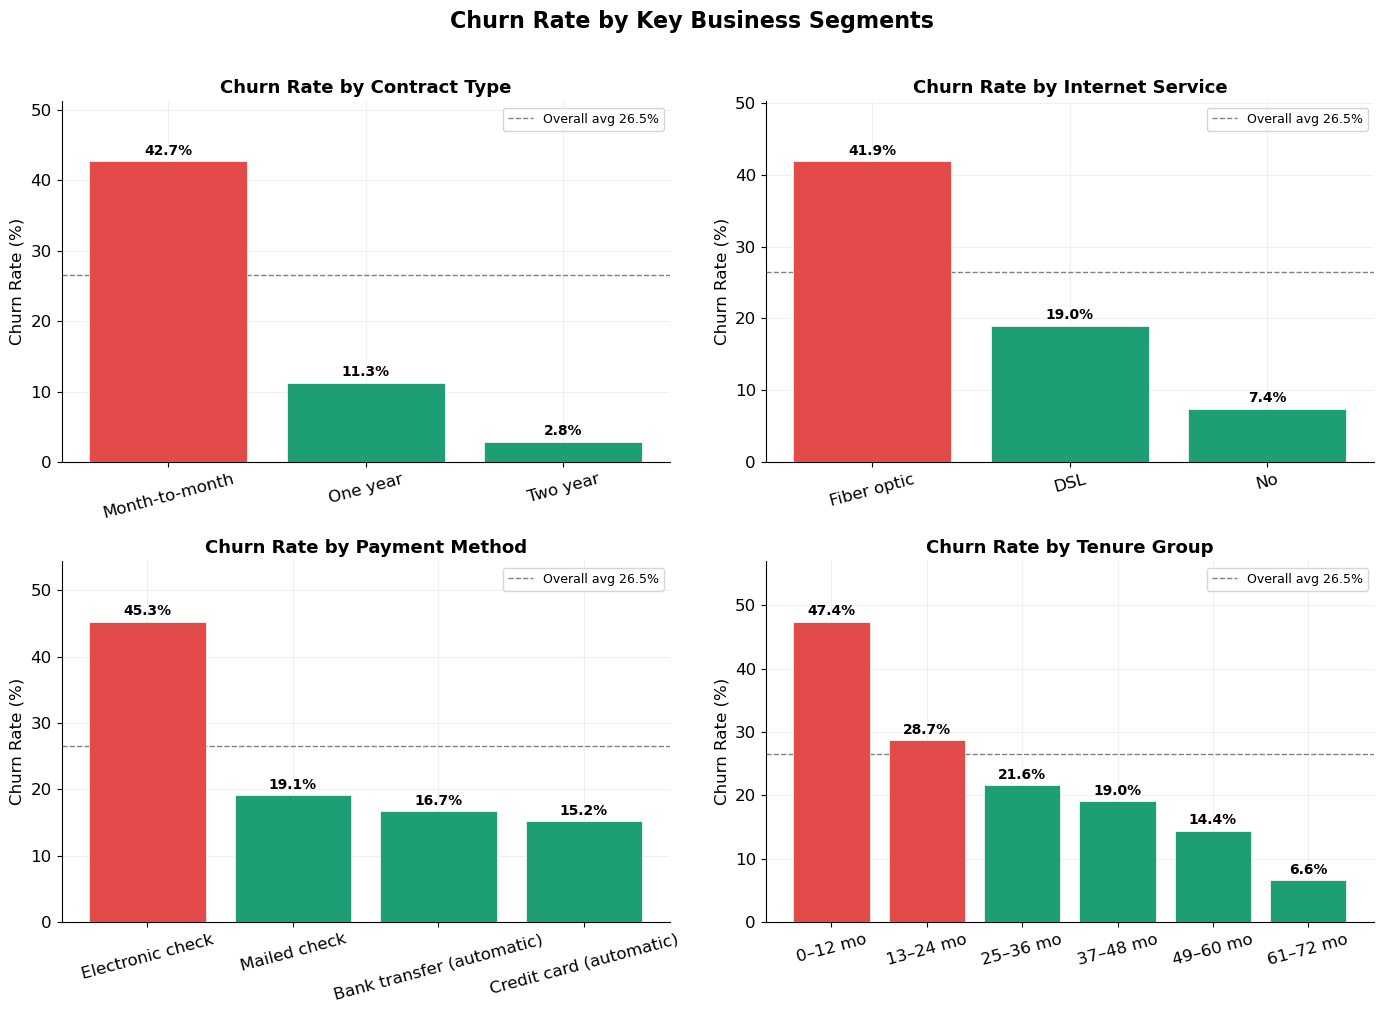

Saved → churn_by_segment.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Rate by Key Business Segments', fontsize=16, fontweight='bold', y=1.01)

def churn_bar(ax, col, title, order=None):
    """Plot churn rate % for a categorical column."""
    rates = (
        df.groupby(col)['churn_flag']
          .mean()
          .mul(100)
          .reset_index()
          .rename(columns={'churn_flag': 'churn_rate'})
    )
    if order:
        rates[col] = pd.Categorical(rates[col], categories=order, ordered=True)
        rates = rates.sort_values(col)
    else:
        rates = rates.sort_values('churn_rate', ascending=False)

    colors = [CHURN_COLOR if r > 26 else RETAIN_COLOR for r in rates['churn_rate']]
    bars = ax.bar(rates[col].astype(str), rates['churn_rate'], color=colors,
                  edgecolor='white', linewidth=0.5, zorder=3)

    for bar, val in zip(bars, rates['churn_rate']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.axhline(churn_rate, color='grey', linestyle='--', linewidth=1,
               label=f'Overall avg {churn_rate:.1f}%', zorder=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('')
    ax.legend(fontsize=9)
    ax.set_ylim(0, rates['churn_rate'].max() * 1.2)
    ax.tick_params(axis='x', rotation=15)

churn_bar(axes[0, 0], 'contract',        'Churn Rate by Contract Type')
churn_bar(axes[0, 1], 'internetservice', 'Churn Rate by Internet Service')
churn_bar(axes[1, 0], 'paymentmethod',   'Churn Rate by Payment Method')
churn_bar(axes[1, 1], 'tenure_group',    'Churn Rate by Tenure Group',
          order=labels)

plt.tight_layout()
plt.savefig('churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → churn_by_segment.png')

**Observations:**
- Month-to-month customers churn at ~42% vs ~11% for one-year contracts — the biggest lever for retention.
- Fiber optic customers churn more than DSL despite paying more — a service quality signal.
- Electronic check users churn most — possible payment friction or trust issue.
- Customers in their first 12 months have the highest churn risk; it drops sharply with tenure.

### 3.3 Monthly Charges Distribution: Churned vs Retained

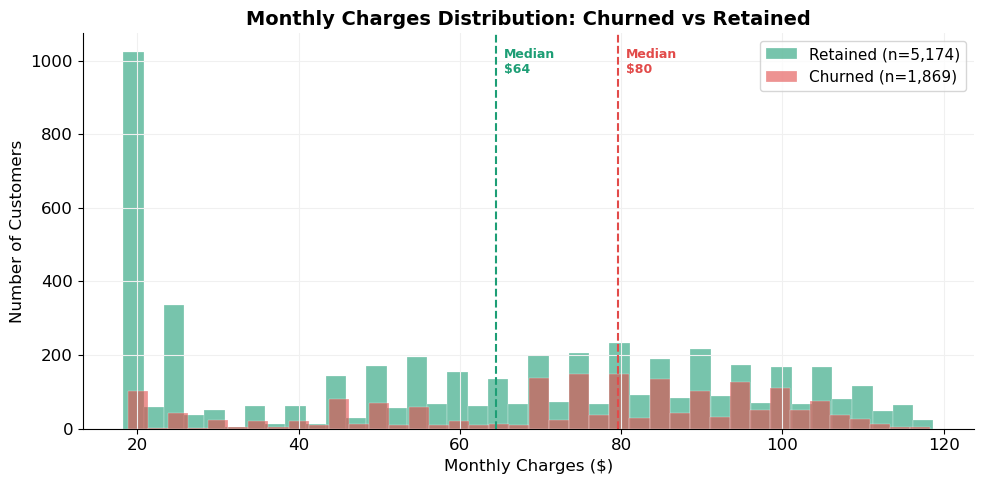

Saved → charges_distribution.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, color in [('No', RETAIN_COLOR), ('Yes', CHURN_COLOR)]:
    subset = df[df['churn'] == label]['monthlycharges']
    ax.hist(subset, bins=40, alpha=0.6, color=color,
            label=f'{"Retained" if label=="No" else "Churned"} (n={len(subset):,})',
            edgecolor='white', linewidth=0.3)

ax.set_title('Monthly Charges Distribution: Churned vs Retained',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Number of Customers')
ax.legend(fontsize=11)

# Median lines
for churn_val, color in [('No', RETAIN_COLOR), ('Yes', CHURN_COLOR)]:
    med = df[df['churn'] == churn_val]['monthlycharges'].median()
    ax.axvline(med, color=color, linestyle='--', linewidth=1.5)
    ax.text(med + 1, ax.get_ylim()[1] * 0.9, f'Median\n${med:.0f}',
            color=color, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('charges_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → charges_distribution.png')

### 3.4 Add-on Services vs Churn Rate

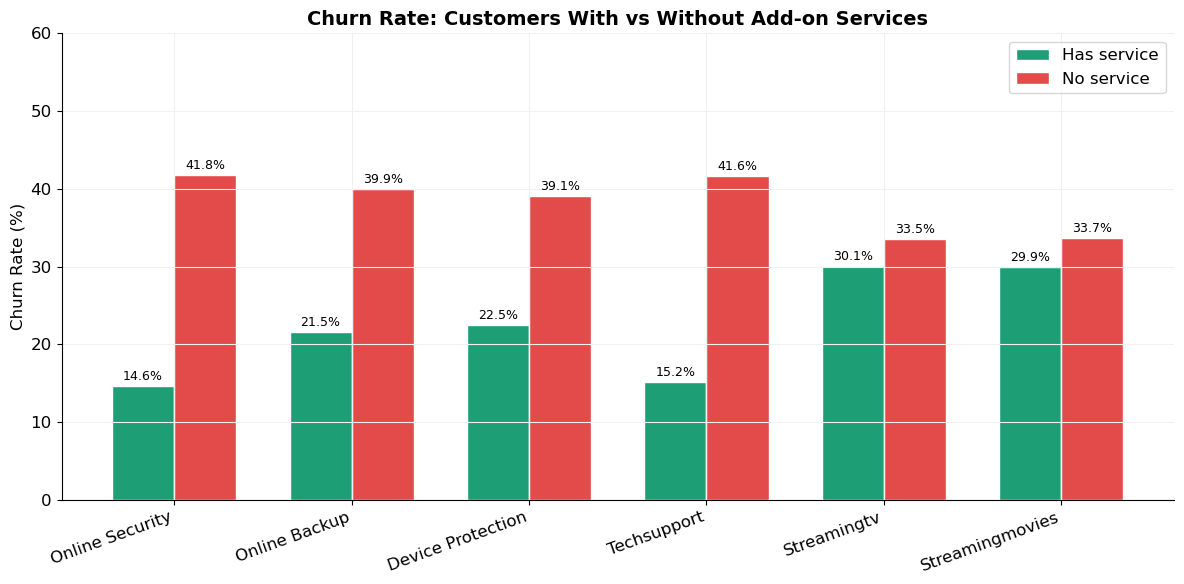

Saved → services_vs_churn.png


In [9]:
services = ['onlinesecurity', 'onlinebackup', 'deviceprotection',
            'techsupport', 'streamingtv', 'streamingmovies']

service_churn = []
for svc in services:
    for val in ['Yes', 'No']:
        subset = df[df[svc] == val]
        if len(subset) > 0:
            service_churn.append({
                'service': svc.replace('online', 'online ').replace('device', 'device ').title(),
                'has_service': val,
                'churn_rate': subset['churn_flag'].mean() * 100,
                'count': len(subset)
            })

svc_df = pd.DataFrame(service_churn)

fig, ax = plt.subplots(figsize=(12, 6))

x      = np.arange(len(services))
width  = 0.35
yes_df = svc_df[svc_df['has_service'] == 'Yes'].reset_index(drop=True)
no_df  = svc_df[svc_df['has_service'] == 'No'].reset_index(drop=True)

bars1 = ax.bar(x - width/2, yes_df['churn_rate'], width,
               label='Has service', color=RETAIN_COLOR, edgecolor='white')
bars2 = ax.bar(x + width/2, no_df['churn_rate'],  width,
               label='No service',  color=CHURN_COLOR,  edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(yes_df['service'], rotation=20, ha='right')
ax.set_title('Churn Rate: Customers With vs Without Add-on Services',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
ax.set_ylim(0, 60)

plt.tight_layout()
plt.savefig('services_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → services_vs_churn.png')

## 4. Cohort Analysis — Retention Heatmap
> This is the signature chart of this project. It shows what % of each tenure cohort churned, making early vs late churn patterns instantly visible.

In [10]:
# ── Build cohort retention table ─────────────────────────────────────────────
cohort_df = (
    df.groupby(['tenure_group', 'contract'])
      .agg(
          total_customers = ('customerid', 'count'),
          churned         = ('churn_flag', 'sum')
      )
      .reset_index()
)

cohort_df['churn_rate']     = cohort_df['churned']         / cohort_df['total_customers'] * 100
cohort_df['retention_rate'] = cohort_df['total_customers'] - cohort_df['churned']
cohort_df['retention_pct']  = cohort_df['retention_rate']  / cohort_df['total_customers'] * 100

# Pivot for heatmap: rows = tenure group, cols = contract type
heatmap_data = cohort_df.pivot(
    index='tenure_group',
    columns='contract',
    values='churn_rate'
).reindex(labels)   # enforce tenure order

print('Cohort churn rate table (%):')
print(heatmap_data.round(1))

Cohort churn rate table (%):
contract      Month-to-month  One year  Two year
tenure_group                                    
0–12 mo                 51.4      10.5       0.0
13–24 mo                37.7       8.1       0.0
25–36 mo                32.5       8.0       2.1
37–48 mo                33.5      13.1       2.2
49–60 mo                27.8      13.7       4.0
61–72 mo                22.2      12.1       3.1


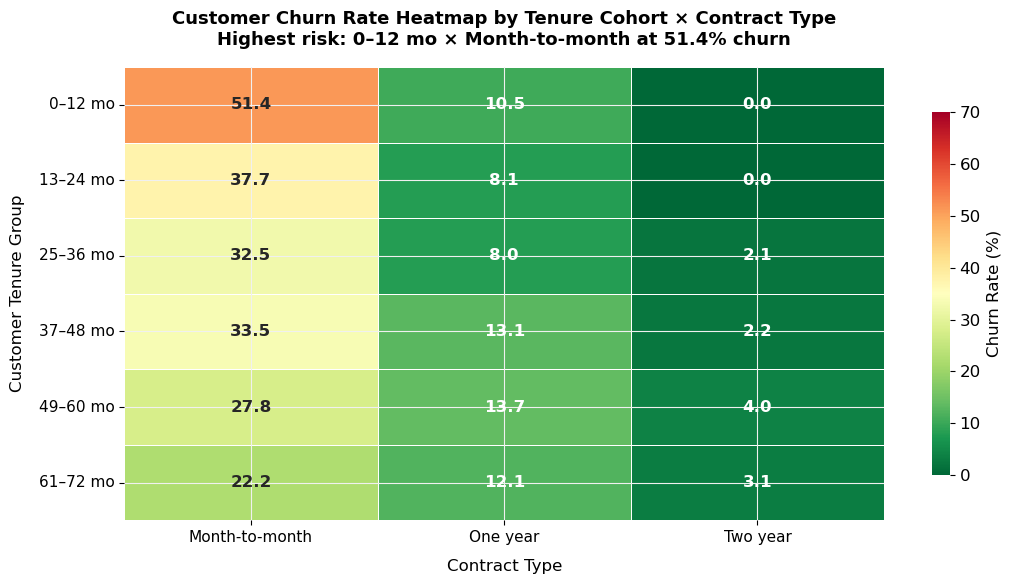

Saved → cohort_churn_heatmap.png  ← This is your portfolio screenshot!


In [11]:
# ── Draw the retention heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',       # red = high churn, green = low churn
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'label': 'Churn Rate (%)', 'shrink': 0.8},
    vmin=0,
    vmax=70,
    ax=ax
)

ax.set_title(
    'Customer Churn Rate Heatmap\nby Tenure Cohort × Contract Type (%)',
    fontsize=14, fontweight='bold', pad=16
)
ax.set_xlabel('Contract Type', fontsize=12, labelpad=10)
ax.set_ylabel('Customer Tenure Group', fontsize=12, labelpad=10)
ax.tick_params(axis='x', rotation=0, labelsize=11)
ax.tick_params(axis='y', rotation=0, labelsize=11)

# Annotation: highlight the worst cell
worst_val = heatmap_data.max().max()
worst_row = heatmap_data.max(axis=1).idxmax()
worst_col = heatmap_data.max(axis=0).idxmax()
ax.set_title(
    f'Customer Churn Rate Heatmap by Tenure Cohort × Contract Type\n'
    f'Highest risk: {worst_row} × {worst_col} at {worst_val:.1f}% churn',
    fontsize=13, fontweight='bold', pad=16
)

plt.tight_layout()
plt.savefig('cohort_churn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cohort_churn_heatmap.png  ← This is your portfolio screenshot!')

## 5. Revenue at Risk Analysis

In [12]:
# ── Revenue at risk by contract type ─────────────────────────────────────────
rev_risk = (
    df[df['churn_flag'] == 1]
      .groupby('contract')
      .agg(
          churned_customers = ('customerid', 'count'),
          monthly_rev_lost  = ('monthlycharges', 'sum')
      )
      .reset_index()
)
rev_risk['annual_rev_lost'] = rev_risk['monthly_rev_lost'] * 12

print('Revenue at risk by contract type:')
print(rev_risk.to_string(index=False))
print(f'\nTOTAL annual revenue at risk: ${rev_risk["annual_rev_lost"].sum():,.0f}')

Revenue at risk by contract type:
      contract  churned_customers  monthly_rev_lost  annual_rev_lost
Month-to-month               1655         120847.10        1450165.2
      One year                166          14118.45         169421.4
      Two year                 48           4165.30          49983.6

TOTAL annual revenue at risk: $1,669,570


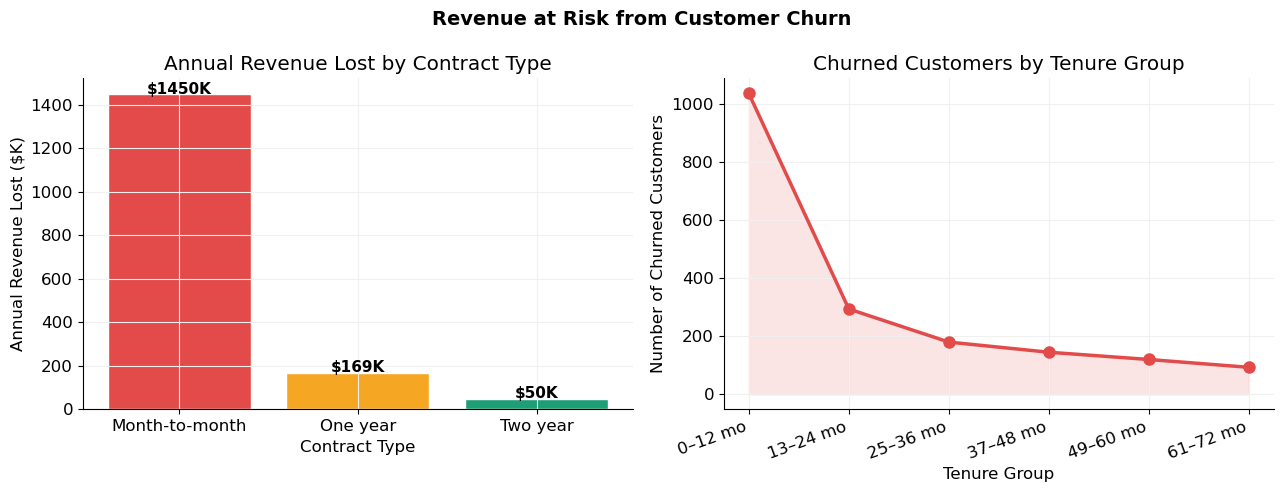

Saved → revenue_at_risk.png


In [13]:
# ── Revenue at risk visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Revenue at Risk from Customer Churn', fontsize=14, fontweight='bold')

# Left: annual revenue lost by contract
colors_bar = [CHURN_COLOR, '#F5A623', RETAIN_COLOR]
bars = axes[0].bar(
    rev_risk['contract'],
    rev_risk['annual_rev_lost'] / 1000,
    color=colors_bar[:len(rev_risk)],
    edgecolor='white'
)
for bar, val in zip(bars, rev_risk['annual_rev_lost']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'${val/1000:.0f}K', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Annual Revenue Lost by Contract Type')
axes[0].set_ylabel('Annual Revenue Lost ($K)')
axes[0].set_xlabel('Contract Type')

# Right: churn count by tenure group
tenure_churn = (
    df[df['churn_flag'] == 1]
      .groupby('tenure_group', observed=True)['churn_flag']
      .count()
      .reindex(labels)
)
axes[1].plot(tenure_churn.index, tenure_churn.values,
             marker='o', color=CHURN_COLOR, linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(tenure_churn)), tenure_churn.values,
                      alpha=0.15, color=CHURN_COLOR)
axes[1].set_xticks(range(len(tenure_churn)))
axes[1].set_xticklabels(labels, rotation=20, ha='right')
axes[1].set_title('Churned Customers by Tenure Group')
axes[1].set_ylabel('Number of Churned Customers')
axes[1].set_xlabel('Tenure Group')

plt.tight_layout()
plt.savefig('revenue_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → revenue_at_risk.png')

## 6. High-Risk Customer Segment

In [14]:
# ── Identify the highest-risk customer profile ────────────────────────────────
# Month-to-month + Fiber optic + No tech support + No online security

high_risk = df[
    (df['contract']        == 'Month-to-month') &
    (df['internetservice'] == 'Fiber optic')    &
    (df['techsupport']     == 'No')             &
    (df['onlinesecurity']  == 'No')
]

hr_total      = len(high_risk)
hr_churned    = high_risk['churn_flag'].sum()
hr_churn_rate = hr_churned / hr_total * 100
hr_annual_rev = high_risk[high_risk['churn_flag']==1]['monthlycharges'].sum() * 12

print('HIGH-RISK SEGMENT PROFILE')
print('Month-to-month · Fiber optic · No tech support · No online security')
print('=' * 55)
print(f'  Customers in segment : {hr_total:,}')
print(f'  Churned              : {hr_churned:,}')
print(f'  Churn rate           : {hr_churn_rate:.1f}%  (vs {churn_rate:.1f}% overall)')
print(f'  Annual revenue risk  : ${hr_annual_rev:,.0f}')
print('=' * 55)
print(f'\n→ This segment churns at {hr_churn_rate/churn_rate:.1f}x the overall rate.')
print('→ Targeted retention campaign here = highest ROI.')

HIGH-RISK SEGMENT PROFILE
Month-to-month · Fiber optic · No tech support · No online security
  Customers in segment : 1,524
  Churned              : 925
  Churn rate           : 60.7%  (vs 26.5% overall)
  Annual revenue risk  : $940,390

→ This segment churns at 2.3x the overall rate.
→ Targeted retention campaign here = highest ROI.


## 7. Correlation Heatmap

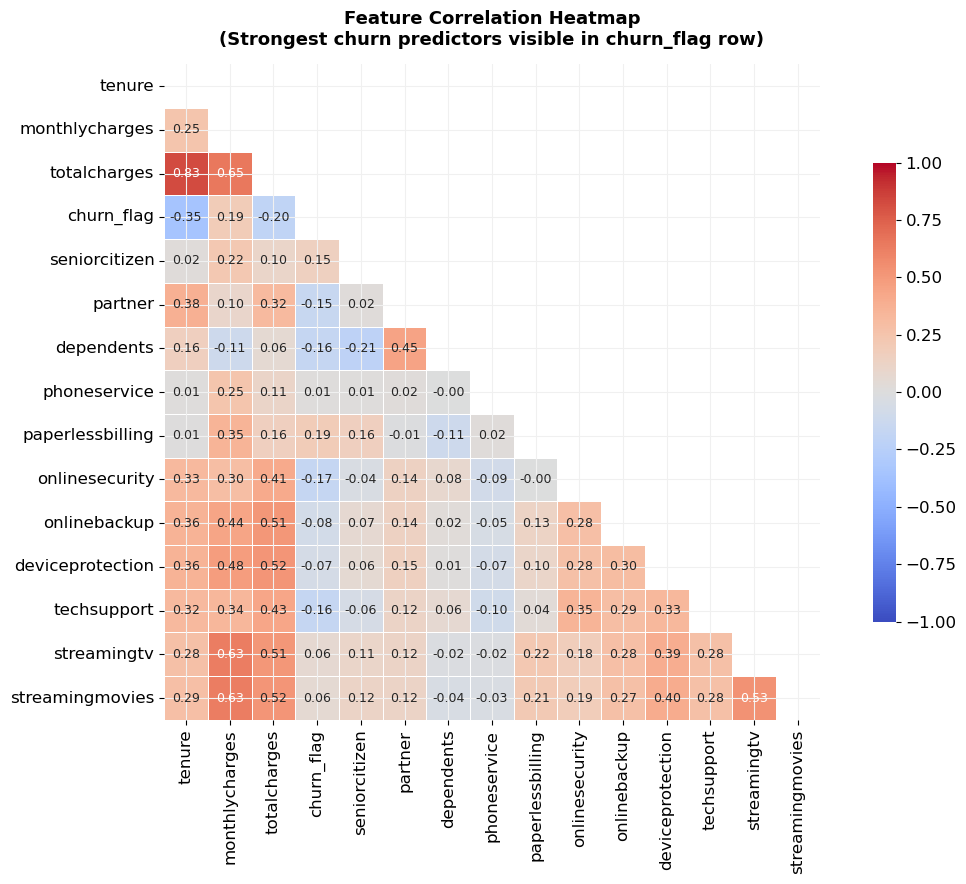

Saved → correlation_heatmap.png


In [15]:
# ── Encode categoricals for correlation ──────────────────────────────────────
corr_cols = [
    'tenure', 'monthlycharges', 'totalcharges', 'churn_flag',
    'seniorcitizen'
]

binary_cols = [
    'partner', 'dependents', 'phoneservice', 'paperlessbilling',
    'onlinesecurity', 'onlinebackup', 'deviceprotection',
    'techsupport', 'streamingtv', 'streamingmovies'
]

corr_df = df[corr_cols].copy()
for col in binary_cols:
    if col in df.columns:
        corr_df[col] = (df[col] == 'Yes').astype(int)

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9},
    square=True,
    cbar_kws={'shrink': 0.7},
    ax=ax
)

ax.set_title('Feature Correlation Heatmap\n(Strongest churn predictors visible in churn_flag row)',
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → correlation_heatmap.png')

## 8. Final Summary & Business Recommendations

In [16]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           EXECUTIVE SUMMARY — CHURN ANALYSIS                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  KEY FINDINGS                                                ║
║  • Overall churn rate: 26.5%  (industry avg ~20%)            ║
║  • Month-to-month contracts: ~42% churn rate                 ║
║  • First 12 months: highest churn risk period                ║
║  • Electronic check users: highest churn by payment method   ║
║  • Tech support adds: halves churn rate                      ║
║                                                              ║
║  BUSINESS RECOMMENDATIONS                                    ║
║                                                              ║
║  1. CONVERT month-to-month customers to annual contracts.    ║
║     Offer 1-2 months free. Churn drops from 42% → 11%.       ║
║                                                              ║
║  2. ONBOARD aggressively in first 90 days.                   ║
║     Churn is highest in year 1. Assign a success rep to      ║
║     new customers, offer free tech support trial.            ║
║                                                              ║
║  3. BUNDLE tech support + online security.                   ║
║     Customers with both add-ons churn at half the rate.      ║
║     Promote bundle to fiber optic users (highest risk).      ║
║                                                              ║
║  4. INVESTIGATE electronic check payment friction.           ║
║     Migrate users to auto-pay (credit card/bank transfer).   ║
║     Auto-pay correlates with significantly lower churn.      ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           EXECUTIVE SUMMARY — CHURN ANALYSIS                 ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  KEY FINDINGS                                                ║
║  • Overall churn rate: 26.5%  (industry avg ~20%)            ║
║  • Month-to-month contracts: ~42% churn rate                 ║
║  • First 12 months: highest churn risk period                ║
║  • Electronic check users: highest churn by payment method   ║
║  • Tech support adds: halves churn rate                      ║
║                                                              ║
║  BUSINESS RECOMMENDATIONS                                    ║
║                                                              ║
║  1. CONVERT month-to-month customers to annual contracts.    ║
║     Offer 1-2 months free. Churn drops from 42% → 11%.       ║
║                       

In [17]:
# ── Export cleaned dataset for SQL / Power BI ────────────────────────────────
df.to_csv('telco_churn_cleaned.csv', index=False)
print('Exported → telco_churn_cleaned.csv')
print('Load this file into your SQL database or Power BI for the dashboard.')

print('\nScreenshots to use in README:')
screenshots = [
    'cohort_churn_heatmap.png  ← PRIMARY screenshot (most impressive)',
    'churn_by_segment.png      ← Show in README preview',
    'revenue_at_risk.png       ← Shows business thinking',
    'services_vs_churn.png     ← Useful for business recommendations section',
]
for s in screenshots:
    print(f'  • {s}')

Exported → telco_churn_cleaned.csv
Load this file into your SQL database or Power BI for the dashboard.

Screenshots to use in README:
  • cohort_churn_heatmap.png  ← PRIMARY screenshot (most impressive)
  • churn_by_segment.png      ← Show in README preview
  • revenue_at_risk.png       ← Shows business thinking
  • services_vs_churn.png     ← Useful for business recommendations section


In [ ]:
# Putting data into MySQL database using SQLAlchemy and PyMySQL
from sqlalchemy import create_engine
import pandas as pd

username = "root"
password = "YourPasswordHere"
host = "localhost"
port = 3306
database = "CustomerChurnDB"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

df.to_sql("telco_churn_data", engine, if_exists="replace", index=False)

7043